In [5]:
import numpy as np 
import pandas as pd 

import statsmodels.api as sm
from ufc_betting.Models.LogisticRegression.utils import save_results
from ufc_betting.Models.LogisticRegression.train_test_builder import TrainTestBuilder
from ufc_betting.config import config

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, brier_score_loss, f1_score


In [6]:
def compute_stacked_features(
    train_feature_sets,
    y_train,
    train_dates,
    scale_encode,
    alphas,
    n_splits=5,
    test_feature_sets=None,
    random_state=42,
):
    """Create grouped OOF Logit features and optional test features.

    Every training prediction comes from a Logit that did not train on
    that row or any other fight occurring on the same date. Test
    predictions come from Logits refitted on the complete training set.
    """
    import warnings
    from sklearn.model_selection import StratifiedGroupKFold
    from statsmodels.tools.sm_exceptions import ConvergenceWarning

    if not train_feature_sets:
        raise ValueError("train_feature_sets cannot be empty")

    y = pd.Series(y_train).reset_index(drop=True)
    dates = pd.to_datetime(pd.Series(train_dates)).dt.normalize().reset_index(drop=True)
    expected_length = len(y)
    if len(dates) != expected_length or any(len(X) != expected_length for X in train_feature_sets.values()):
        raise ValueError("All training feature sets, labels, and dates must align")
    if set(alphas) != set(train_feature_sets):
        raise ValueError("alphas must contain one value for every feature set")
    if n_splits > dates.nunique():
        raise ValueError("n_splits cannot exceed the number of event dates")
    if test_feature_sets is not None and set(test_feature_sets) != set(train_feature_sets):
        raise ValueError("Training and test feature-set names must match")

    def fit_predict(X_fit, y_fit, X_predict, alpha):
        cat_cols = X_fit.select_dtypes('category').columns
        num_cols = X_fit.select_dtypes('number').columns
        scaled = scale_encode(
            X_train=X_fit, X_test=X_predict,
            cat_cols=cat_cols, num_cols=num_cols,
        )
        X_fit_sm = sm.add_constant(scaled['X_train'], has_constant='add')
        X_predict_sm = sm.add_constant(scaled['X_test'], has_constant='add')
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', ConvergenceWarning)
            model = sm.Logit(np.asarray(y_fit), X_fit_sm).fit_regularized(
                method='l1', alpha=alpha, disp=False,
            )
        return np.asarray(model.predict(X_predict_sm))

    splitter = StratifiedGroupKFold(
        n_splits=n_splits, shuffle=True, random_state=random_state,
    )
    splits = list(splitter.split(np.zeros(expected_length), y, groups=dates))
    stacked_train = {}
    stacked_test = {}

    for name, X in train_feature_sets.items():
        oof_probability = np.empty(expected_length, dtype=float)
        for fit_idx, holdout_idx in splits:
            oof_probability[holdout_idx] = fit_predict(
                X.iloc[fit_idx], y.iloc[fit_idx], X.iloc[holdout_idx], alphas[name],
            )
        stacked_train[f'proba_red_{name}'] = oof_probability

        if test_feature_sets is not None:
            stacked_test[f'proba_red_{name}'] = fit_predict(
                X, y, test_feature_sets[name], alphas[name],
            )

    X_stacked_train = pd.DataFrame(stacked_train)
    X_stacked_test = (
        pd.DataFrame(stacked_test) if test_feature_sets is not None else None
    )
    return X_stacked_train, X_stacked_test


In [7]:
df_test_open = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_open.csv')
df_test_close1 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_close1.csv')
df_test_close2 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_close2.csv')

df_train_open = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\train_logit_open.csv')
df_train_close1 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\train_logit_close1.csv')
df_train_close2 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\train_logit_close2.csv')

fp = r'C:\Users\jcmar\my_files\SportsBetting\data\training_data\entire_odds_stats_2026-03-07.csv'
df_model = pd.read_csv(fp)


In [ ]:
# Build the three leakage-free stacked probability features below before fitting a meta-model.

Index(['proba_fair_close1_diff', 'proba_fair_open_diff', 'reach_diff',
       'sub_att_pm_red', 'sub_att_pm_blue', 'ratio_control_diff',
       'td_landed_pm_diff', 'ratio_td_diff', 'adjusted_td_red',
       'adjusted_td_blue', 'sig_str_absorbed_total_diff',
       'sig_str_accuracy_pct_diff', 'sig_str_defense_pct_diff',
       'adjusted_sig_str_blue', 'adjusted_sig_str_red', 'win_pct_red',
       'win_pct_blue', 'win_streak_diff', 'lose_streak_diff', 'elo_red',
       'elo_blue', 'elo_pred', 'age_red', 'age_blue', 'dec_fair_close1_red',
       'dec_fair_close1_blue', 'dec_close1_red', 'dec_close1_blue',
       'fighter_red', 'fighter_blue', 'winner', 'date', 'open_red',
       'open_blue', 'close1_red', 'close1_blue', 'close2_red', 'close2_blue',
       'num_wins_red', 'num_wins_blue', 'num_losses_red', 'num_losses_blue',
       'proba_se', 'proba_red', 'proba_blue', 'pred_winner', 'correct_pred',
       'prob_winner'],
      dtype='str')


In [8]:

def obs_per_fighter(df_test): 

    dat = []
    for _, row in df_test.iterrows():

        pred_winner = row['pred_winner'] == 1
        total_fights_red = row['num_wins_red'] + row['num_losses_red']
        total_fights_blue = row['num_wins_blue'] + row['num_losses_blue']
        total_fights_pred = total_fights_red if pred_winner else total_fights_blue
        total_fights_loser = total_fights_blue if pred_winner else total_fights_red
        total_fights_diff = total_fights_pred - total_fights_loser

        new_row = [total_fights_red, total_fights_blue, total_fights_pred, total_fights_loser, total_fights_diff]
        dat.append(new_row)
    
    return np.array(dat)


def fighter_historical_accuracy(df):

    df = df.copy()

    # ensure chronological order
    # df = df.sort_values('date')

    fighter_stats = {}

    red_acc = []
    blue_acc = []

    for _, row in df.iterrows():

        fighter_red = row['fighter_red']
        fighter_blue = row['fighter_blue']

        winner = row['winner']

        # get prior stats only (no current-row leakage)
        red_wins, red_total = fighter_stats.get(fighter_red, (0, 0))
        blue_wins, blue_total = fighter_stats.get(fighter_blue, (0, 0))

        # historical accuracy BEFORE current fight
        red_hist_acc = (
            red_wins / red_total
            if red_total > 0 else np.nan
        )

        blue_hist_acc = (
            blue_wins / blue_total
            if blue_total > 0 else np.nan
        )

        red_acc.append(red_hist_acc)
        blue_acc.append(blue_hist_acc)

        # update AFTER recording historical values
        if winner == 1:
            fighter_stats[fighter_red] = (red_wins + 1, red_total + 1)
            fighter_stats[fighter_blue] = (blue_wins, blue_total + 1)

        else:
            fighter_stats[fighter_red] = (red_wins, red_total + 1)
            fighter_stats[fighter_blue] = (blue_wins + 1, blue_total + 1)

    df['fighter_red_hist_winrate'] = red_acc
    df['fighter_blue_hist_winrate'] = blue_acc

    return df


(tf_red_open_train, tf_blue_open_train, tf_pred_open_train, tf_loser_open_train, tf_diff_open_train) = obs_per_fighter(df_train_open).T
(tf_red_open_test, tf_blue_open_test, tf_pred_open_test, tf_loser_open_test, tf_diff_open_test) = obs_per_fighter(df_test_open).T

(tf_red_close1_train, tf_blue_close1_train, tf_pred_close1_train, tf_loser_close1_train, tf_diff_close1_train) = obs_per_fighter(df_train_close1).T
(tf_red_close1_test, tf_blue_close1_test, tf_pred_close1_test, tf_loser_close1_test, tf_diff_close1_test) = obs_per_fighter(df_test_close1).T


(tf_red_close2_train, tf_blue_close2_train, tf_pred_close2_train, tf_loser_close2_train, tf_diff_close2_train) = obs_per_fighter(df_train_close2).T
(tf_red_close2_test, tf_blue_close2_test, tf_pred_close2_test, tf_loser_close2_test, tf_diff_close2_test) = obs_per_fighter(df_test_close2).T


In [9]:
feature_columns_by_odds = {
    'open': config.open_feats,
    'close1': config.close1_feats,
    'close2': config.close2_feats,
}
alphas_by_odds = {
    'open': 3.699,
    'close1': 6.68,
    'close2': 3.891,
}
combined_features = list(dict.fromkeys(
    feature
    for columns in feature_columns_by_odds.values()
    for feature in columns
))

stack_builder = TrainTestBuilder(
    df=df_model, feats=combined_features, target_col='winner',
    date_col='date', odds_type='close2',
    year=2010, month=2, day=26,
)
stack_pkt = stack_builder.prepare_train_test(train_size=0.85, scale=False)

train_feature_sets = {
    odds_type: stack_pkt['X_train'][columns].copy()
    for odds_type, columns in feature_columns_by_odds.items()
}
test_feature_sets = {
    odds_type: stack_pkt['X_test'][columns].copy()
    for odds_type, columns in feature_columns_by_odds.items()
}
y_train = stack_pkt['y_train'].reset_index(drop=True)
y_test = stack_pkt['y_test'].reset_index(drop=True)
df_stacked_test = stack_pkt['test_df'].reset_index(drop=True)

X_stacked_train, X_stacked_test = compute_stacked_features(
    train_feature_sets=train_feature_sets,
    y_train=y_train,
    train_dates=stack_pkt['dates_train'],
    scale_encode=stack_builder.scale_encode,
    alphas=alphas_by_odds,
    n_splits=5,
    test_feature_sets=test_feature_sets,
)
assert X_stacked_train.columns.tolist() == [
    'proba_red_open', 'proba_red_close1', 'proba_red_close2'
]

Filtered: kept 4339 rows from 2010-02-26 onward.
PREPARE SHAPE: (4339, 43)


In [10]:
X_stacked_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 3688 entries, 0 to 3687
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   proba_red_open    3688 non-null   float64
 1   proba_red_close1  3688 non-null   float64
 2   proba_red_close2  3688 non-null   float64
dtypes: float64(3)
memory usage: 86.6 KB


In [11]:
def logit_stacked(X_train, y_train, X_test, y_test, alpha=3):
    # add intercept
    X_train_const = sm.add_constant(X_train)
    model = sm.Logit(y_train, X_train_const).fit_regularized(
                        method='l1', alpha=alpha, disp=False
                    )

    # fit
    print(model.summary())

    X_test_const = sm.add_constant(X_test, has_constant='add')
    pred_proba_test = model.predict(X_test_const)
    test_accuracy = ((pred_proba_test >= 0.5) == y_test).mean()

    pred = model.get_prediction(X_test_const)
    pred_summary = pred.summary_frame()
    print(pred_summary)

    # brier score
    brier = brier_score_loss(y_test, pred_proba_test)

    print("Accuracy:", test_accuracy)
    print("Brier Score:", brier)
    print('F1 Score: ', f1_score(y_test, (pred_proba_test >= 0.5)))

    return model, pred_proba_test, test_accuracy, brier


In [20]:
logit_model, pred_proba_test, test_accuracy, brier = logit_stacked(X_stacked_train, y_train, X_stacked_test, y_test, alpha=3)

                           Logit Regression Results                           
Dep. Variable:                 winner   No. Observations:                 3688
Model:                          Logit   Df Residuals:                     3686
Method:                           MLE   Df Model:                            1
Date:                Wed, 09 Sep 2026   Pseudo R-squ.:                 0.09187
Time:                        20:40:31   Log-Likelihood:                -2290.4
converged:                       True   LL-Null:                       -2522.1
Covariance Type:            nonrobust   LLR p-value:                8.739e-103
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -2.0395      0.124    -16.512      0.000      -2.282      -1.797
proba_red_open            0        nan        nan        nan         nan         nan
proba_red_close1     4.1453 

In [15]:
df_results_close1 = save_results(df_stacked_test, pred_proba_test, r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_stack_close1.csv')
df_results_close2 = save_results(df_stacked_test, pred_proba_test, r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_stack_close2.csv')


In [23]:
df_results_close2.columns

Index(['proba_fair_open_diff', 'reach_diff', 'sub_att_pm_red',
       'sub_att_pm_blue', 'ratio_control_diff', 'td_landed_pm_diff',
       'ratio_td_diff', 'adjusted_td_red', 'adjusted_td_blue',
       'sig_str_absorbed_total_diff', 'sig_str_accuracy_pct_diff',
       'sig_str_defense_pct_diff', 'adjusted_sig_str_blue',
       'adjusted_sig_str_red', 'win_pct_red', 'win_pct_blue',
       'win_streak_diff', 'lose_streak_diff', 'elo_red', 'elo_blue',
       'elo_pred', 'age_red', 'age_blue', 'proba_fair_close1_diff',
       'proba_fair_close2_diff', 'dec_fair_close2_red', 'dec_fair_close2_blue',
       'dec_close2_red', 'dec_close2_blue', 'fighter_red', 'fighter_blue',
       'winner', 'date', 'open_red', 'open_blue', 'close1_red', 'close1_blue',
       'close2_red', 'close2_blue', 'num_wins_red', 'num_wins_blue',
       'num_losses_red', 'num_losses_blue', 'proba_red', 'proba_blue',
       'pred_winner', 'correct_pred', 'prob_winner'],
      dtype='str')

In [22]:
df_results_close1.columns

Index(['proba_fair_open_diff', 'reach_diff', 'sub_att_pm_red',
       'sub_att_pm_blue', 'ratio_control_diff', 'td_landed_pm_diff',
       'ratio_td_diff', 'adjusted_td_red', 'adjusted_td_blue',
       'sig_str_absorbed_total_diff', 'sig_str_accuracy_pct_diff',
       'sig_str_defense_pct_diff', 'adjusted_sig_str_blue',
       'adjusted_sig_str_red', 'win_pct_red', 'win_pct_blue',
       'win_streak_diff', 'lose_streak_diff', 'elo_red', 'elo_blue',
       'elo_pred', 'age_red', 'age_blue', 'proba_fair_close1_diff',
       'proba_fair_close2_diff', 'dec_fair_close2_red', 'dec_fair_close2_blue',
       'dec_close2_red', 'dec_close2_blue', 'fighter_red', 'fighter_blue',
       'winner', 'date', 'open_red', 'open_blue', 'close1_red', 'close1_blue',
       'close2_red', 'close2_blue', 'num_wins_red', 'num_wins_blue',
       'num_losses_red', 'num_losses_blue', 'proba_red', 'proba_blue',
       'pred_winner', 'correct_pred', 'prob_winner'],
      dtype='str')

In [20]:
assert X_stacked_train.columns.tolist() == ['proba_red_open', 'proba_red_close1', 'proba_red_close2']

In [24]:
# model
model = XGBClassifier(
    n_estimators=200,
    max_depth=2,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
)

# train
model.fit(X_stacked_train, y_train)

# predicted probabilities
test_probs = model.predict_proba(X_stacked_test)
pred_proba = model.predict_proba(X_stacked_test)[:, 1]

# predicted class
pred_class = (pred_proba >= 0.5).astype(int)

# metrics
test_accuracy = accuracy_score(y_test, pred_class)
brier = brier_score_loss(y_test, pred_proba)
f1 = f1_score(y_test, pred_class)
print("Test Accuracy:", test_accuracy)
print("Brier Score:", brier)
print('F1 Score: ', f1)

Test Accuracy: 0.7096774193548387
Brier Score: 0.19578827917575836
F1 Score:  0.7435549525101763


In [25]:
train_proba = model.predict_proba(X_stacked_train)[:,1]
train_pred_class = (train_proba >= .5).astype(int)

print('Train Accuracy: ', accuracy_score(y_train, train_pred_class))
print('Train Brier: ', brier_score_loss(y_train, train_proba))
print('Train F1: ', f1_score(y_train, train_pred_class))

Train Accuracy:  0.6664859002169198
Train Brier:  0.20868702232837677
Train F1:  0.7245857590685177


In [26]:
df_results_close1 = save_results(df_stacked_test, pred_proba, r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_xboost_stack_close1.csv')
df_results_close2 = save_results(df_stacked_test, pred_proba, r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_xboost_stack_close2.csv')


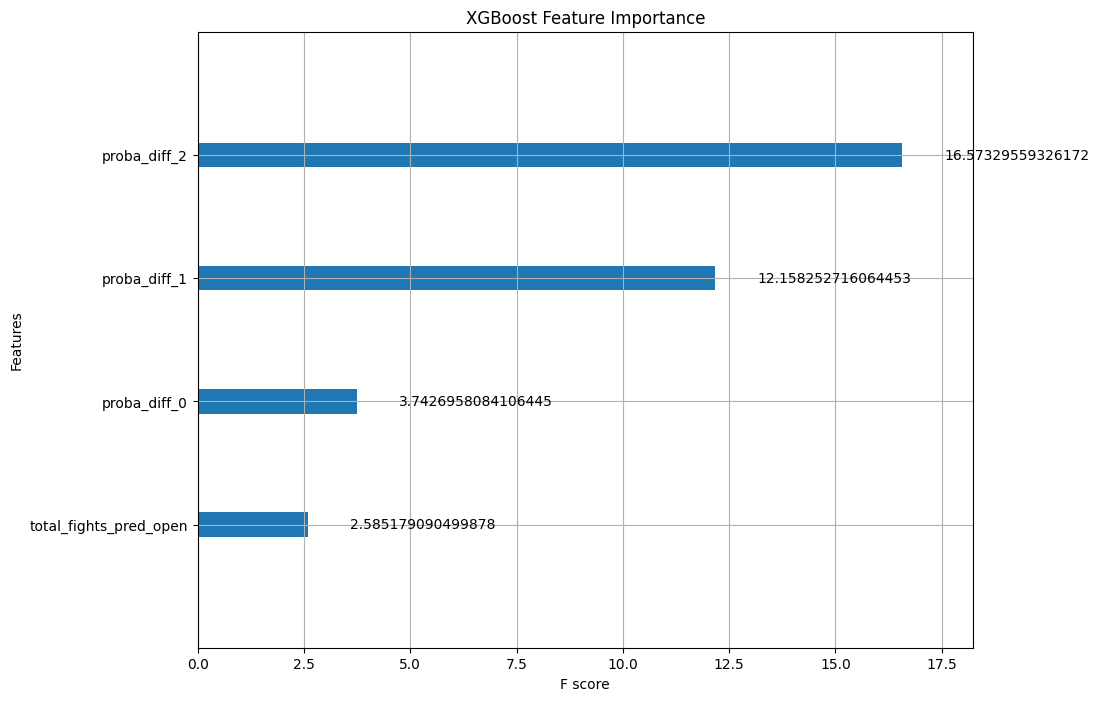

: 

In [ ]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

plot_importance(
    model,
    ax=ax,
    importance_type='gain',   # 'weight', 'gain', 'cover'
    max_num_features=20
)

plt.title("XGBoost Feature Importance")
plt.show()

In [24]:
df_results_close1 = save_results(df_stacked_test, pred_proba, r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_xboost_stack_close1.csv')
df_results_close2 = save_results(df_stacked_test, pred_proba, r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_xboost_stack_close2.csv')



In [111]:
model.save_model(r"C:\\Users\\jcmar\\my_files\\SportsBetting\\data\\saved_models\\xgboost_stacked.pkl")
    

c:\Users\jcmar\my_files\SportsBetting\venv\Lib\site-packages\xgboost\core.py:158: UserWarning: [00:13:47] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  warnings.warn(smsg, UserWarning)
